In [13]:
import numpy as np
from PIL import Image
A = np.fromfile( 'rle.bin', dtype='<u4' )
rows = int(A[0])
columns = int(A[1])
binary_array = ""
option = 0
iters = 0
for i in A[2:]:
        loops = int(i)
        for j in range(0, loops):
            if option == 0:
                binary_array += '0'
            else:
                binary_array += '1'
        if option == 0:
            option = 1
        else:
            option = 0
image = np.zeros((rows, columns))
index = 0
for j in range(0, columns):
    for i in range(0,rows):
            image[i][j] = binary_array[index]
            index += 1
img_colors = (1-image)*255 # 1=black 0=white
img = Image.fromarray(img_colors)
img.show()

Looks like two people-ish things on horses. I do not recognize the characters though.

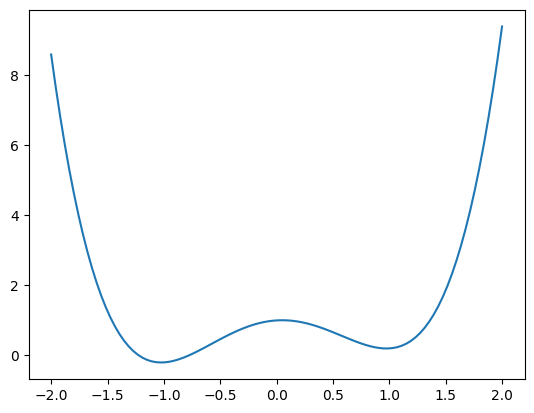

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Define the mathematical function
def f(x):
    return ((x**2) - 1)**2 + 0.2 * x

def df(x):
    return 4*x*((x**2)-1)+0.2

# Generate 400 evenly spaced values between -2 and 2
x = np.linspace(-2, 2, 100)
y = f(x)
plt.plot(x, y)
plt.show()

In [15]:
def subder(x0, a, M):
    x=x0
    xbest=x0
    fxBest = f(xbest)
    fxBestNotUpdated = 0
    while fxBestNotUpdated < M and (abs(df(x))>10**(-8)):
        g = df(x)
        x = x-(a*g)
        fx = f(x)
        if fx < fxBest:
            xbest = x
            fxBest =fx
        else: fxBestNotUpdated += 1
    return (xbest, fxBest)

In [16]:
subder(1.5, 0.05, 500)

(0.9739943548170674, 0.19743415285827653)

In [17]:
subder(-1.5, 0.05, 500)

(-1.0241203015747595, -0.20244043434482245)

In [18]:
def f2(x):
    return (x-3)**2

In [19]:
def df2(x):
    return 2*(x-3)

In [20]:

def subder2(x0, a, M):
    x_array = []
    y_array = []
    iteration = 0
    x=x0
    xbest=x0
    fxBest = f2(xbest)
    fxBestNotUpdated = 0
    while fxBestNotUpdated < M and (abs(df2(x))>10**(-8)):
        g = df2(x)
        x = x-(a*g)
        fx = f2(x)
        if fx < fxBest:
            xbest = x
            fxBest =fx
        else: fxBestNotUpdated += 1
        iteration += 1
        x_array.append(iteration)
        y_array.append(fx)
    plt.plot(x_array, y_array)
    plt.show()
    return (xbest, fxBest)

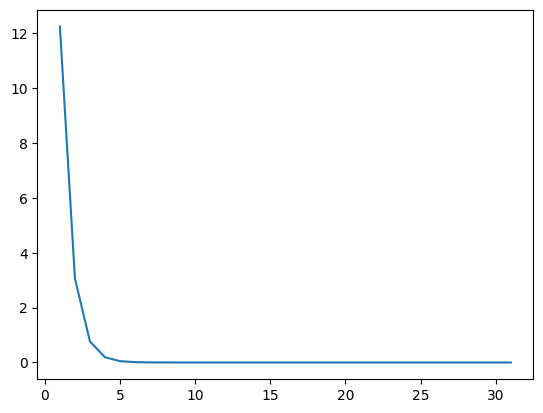

(3.000000003259629, 1.0625181290357943e-17)

In [21]:
subder2(10, 0.25, 25)

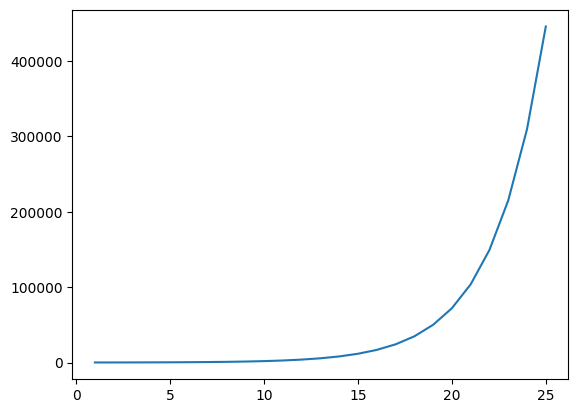

(10, 49)

In [22]:
subder2(10, 1.1, 25)

In [40]:
def armijo_line_search(x, alpha_start=1.1, c=1e-4, rho=0.5):
    a=alpha_start
    g=df2(x)
    while f2(x-(a*g)) > f2(x) - (c*a*g**2):
        a *= rho
    return a



In [41]:
def subder3(x0, a, M):
    x_array = []
    y_array = []
    a_array = []
    iteration = 0
    x=x0
    xbest=x0
    fxBest = f2(xbest)
    fxBestNotUpdated = 0
    while fxBestNotUpdated < M and (abs(df2(x))>10**(-8)):
        g = df2(x)
        x = x-(a*g)
        fx = f2(x)
        if fx < fxBest:
            xbest = x
            fxBest =fx
        else: fxBestNotUpdated += 1
        iteration += 1
        x_array.append(iteration)
        y_array.append(fx)
        a_array.append(a)
        a = armijo_line_search(x, a)
    fig, axs = plt.subplots(1, 2)
    axs[0].plot(x_array, y_array, color='tab:blue')
    axs[1].plot(x_array, a_array, color='tab:orange')
    print(a_array)
    plt.tight_layout()
    plt.show()
    return (xbest, fxBest)

[1.1, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55, 0.55]


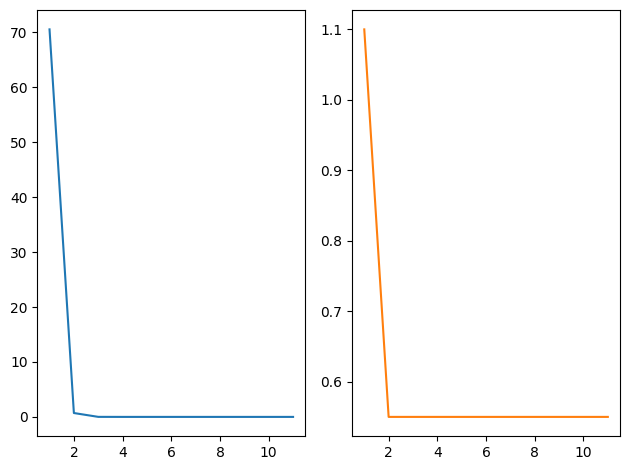

(2.99999999916, 7.056001167632164e-19)

In [42]:
subder3(10, 1.1, 25)

In [ ]:
import random
def get_random_subderivative(x):
    g = 2 * (x - 1)
    if x > -2:
        g += 3
    elif x < -2:
        g -= 3
    else:
        g += random.uniform(-3, 3)
    if x > 2.5:
        g += 2
    elif x < 2.5:
        g -= 2
    else:
        g += random.uniform(-2, 2)
    return g

In [ ]:
def bisection_minimize(a, b, tol=1e-6):
    iterations = 0
    # To guarantee the returned midpoint is within `tol` of the true minimum,
    # the total interval length must be <= 2 * tol.
    while (b - a) > 2 * tol:
        mid = (a + b) / 2.0
        g = get_random_subderivative(mid)
        if g > 0:
            b = mid
        elif g < 0:
            a = mid
        else:
            return mid, iterations
        iterations += 1
        
    return (a + b) / 2.0, iterations
# Run minimization over [-4, 4]
x_optimal, num_iterations = bisection_minimize(-4, 4, 1e-6)
print(f"Estimated x: {x_optimal}")
print(f"Iterations: {num_iterations}")

Estimated x: 0.5
Iterations: 3
